# DSC 640 — Data Presentation & Visualization
## Manoj K Kola
## Weeks 5 & 6
### Term Project — Milestone 3: Medium 2 — Interactive Dashboard

---
#### Design Narrative

This dashboard is designed for **policy analysts, researchers, and government agencies** with moderate data literacy. The color palette uses a teal-to-dark-blue spectrum to project trustworthiness and data authority — consistent with policy-facing communications. Chart backgrounds are kept white to maximize contrast and readability, while muted gray grid lines reduce visual noise without eliminating reference structure.

Each of the four visualizations serves a distinct analytical purpose, avoiding overlap with the PowerPoint (which focuses on trend lines and bar comparisons) and the infographic (which uses icons and big statistics). The heatmap reveals geographic × temporal interactions; the scatter plot shows the income–cost relationship; the stacked bar chart breaks down care-type composition; and the box plot surfaces distributional variation. Titles are set at 14pt bold, axis labels at 11pt, and tick labels at 9pt — a hierarchy that guides the eye without crowding. Consistent use of `tight_layout()` and a shared figure DPI of 150 ensures crisp rendering at standard notebook width.

---
#### Import Libraries & the Datasets

In [21]:
# Import required libraries for data analysis and visualization
import pandas as pd              # For data manipulation
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For plotting charts
import matplotlib.ticker as mticker  # For formatting axis ticks
import seaborn as sns            # For advanced visualizations
import warnings                  # To manage warning messages

# Ignore warning messages for cleaner output
warnings.filterwarnings('ignore')

# Set default plotting style for better visuals
plt.rcParams.update({
    'font.family': 'DejaVu Sans',   # Set font style
    'axes.spines.top': False,       # Remove top border of plots
    'axes.spines.right': False,     # Remove right border of plots
    'axes.grid': True,              # Enable grid lines
    'grid.alpha': 0.3,              # Set grid transparency
    'grid.color': '#CCCCCC'         # Set grid color
})

# Define color palette for consistent visualization styling
PALETTE_MAIN  = '#028090'   # Primary color
PALETTE_SEC   = '#0D5C63'   # Secondary color
PALETTE_DARK  = '#021B21'   # Dark color
PALETTE_LIGHT = '#A8DADC'   # Light color
PALETTE_ACCENT= '#E63946'   # Highlight/accent color

# Print confirmation message
print('Libraries loaded successfully.')

Libraries loaded successfully.


#### Data Loading & Preparation

The National Database of Childcare Prices (NDCP) is a county-level dataset compiled by the U.S. Department of Labor Women's Bureau, covering 2008–2018. 

In [39]:
# Load the NDCP dataset from an Excel file
df = pd.read_excel("nationaldatabaseofchildcareprices.xlsx")

# Rename columns for easier understanding and usage
df = df.rename(columns={
    'StudyYear': 'Year',
    'State_Abbreviation': 'State'
})

# Keep only the required columns for analysis
df = df[['State_Name','State','Year','MCInfant','MCToddler','MCPreschool',
         'MFCCInfant','MFCCToddler','MFCCPreschool','MHI']]

# Data cleaning steps

# Convert selected columns to numeric (handles invalid values)
cols = ['MCInfant','MCToddler','MCPreschool',
        'MFCCInfant','MFCCToddler','MFCCPreschool','MHI']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Remove rows with missing values
df = df.dropna()

# Aggregate data at State-Year level (combine county-level data)
df_state = df.groupby(['State_Name', 'State', 'Year']).agg({
    'MCInfant': 'mean',
    'MCToddler': 'mean',
    'MCPreschool': 'mean',
    'MFCCInfant': 'mean',
    'MFCCToddler': 'mean',
    'MFCCPreschool': 'mean',
    'MHI': 'mean'
}).reset_index()

# Round values for cleaner output
df_state = df_state.round(1)

# Show dataset size after aggregation
print(f"Aggregated dataset shape: {df_state.shape}\n")

# Preview first few rows
df_state.head()

# Create new calculated metrics

# Convert weekly childcare costs into annual costs (52 weeks)
df_state['AnnualCost_CBInfant']  = df_state['MCInfant'] * 52
df_state['AnnualCost_CBToddler'] = df_state['MCToddler'] * 52
df_state['AnnualCost_CBPre']     = df_state['MCPreschool'] * 52

# Calculate childcare cost as percentage of income
df_state['PctIncome_Infant'] = (
    df_state['AnnualCost_CBInfant'] / df_state['MHI'] * 100
).round(1)

# Final output check
print(f"\nDataset shape: {df_state.shape}\n")

# Display selected columns for review
df_state[['State','Year','MCInfant','MCToddler','MCPreschool',
          'MFCCInfant','MFCCToddler','MFCCPreschool','MHI']].head()

Aggregated dataset shape: (381, 10)


Dataset shape: (381, 14)



,State,Year,MCInfant,MCToddler,MCPreschool,MFCCInfant,MFCCToddler,MFCCPreschool,MHI
0,AL,2008,96.8,96.8,87.5,85.0,85.1,83.2,36474.8
1,AL,2009,98.4,98.4,89.2,86.4,86.4,84.7,36088.1
2,AL,2010,99.9,99.9,90.9,87.7,87.8,86.2,36962.9
3,AL,2011,101.4,101.4,92.6,89.0,89.2,87.6,37656.1
4,AL,2012,103.0,103.0,94.3,90.4,90.6,89.1,37812.7


#### Visualization 1 — Heatmap: Median Weekly Infant Care Cost by State & Year

**Purpose:** Reveal geographic and temporal variation simultaneously. Darker teal cells indicate higher costs; the diagonal gradient from left to right shows the national upward trend.

**Audience use case:** A policy analyst can immediately identify which states have been consistently expensive over the full decade (dark rows) vs. those that have grown rapidly (rows that lighten noticeably from left to right).

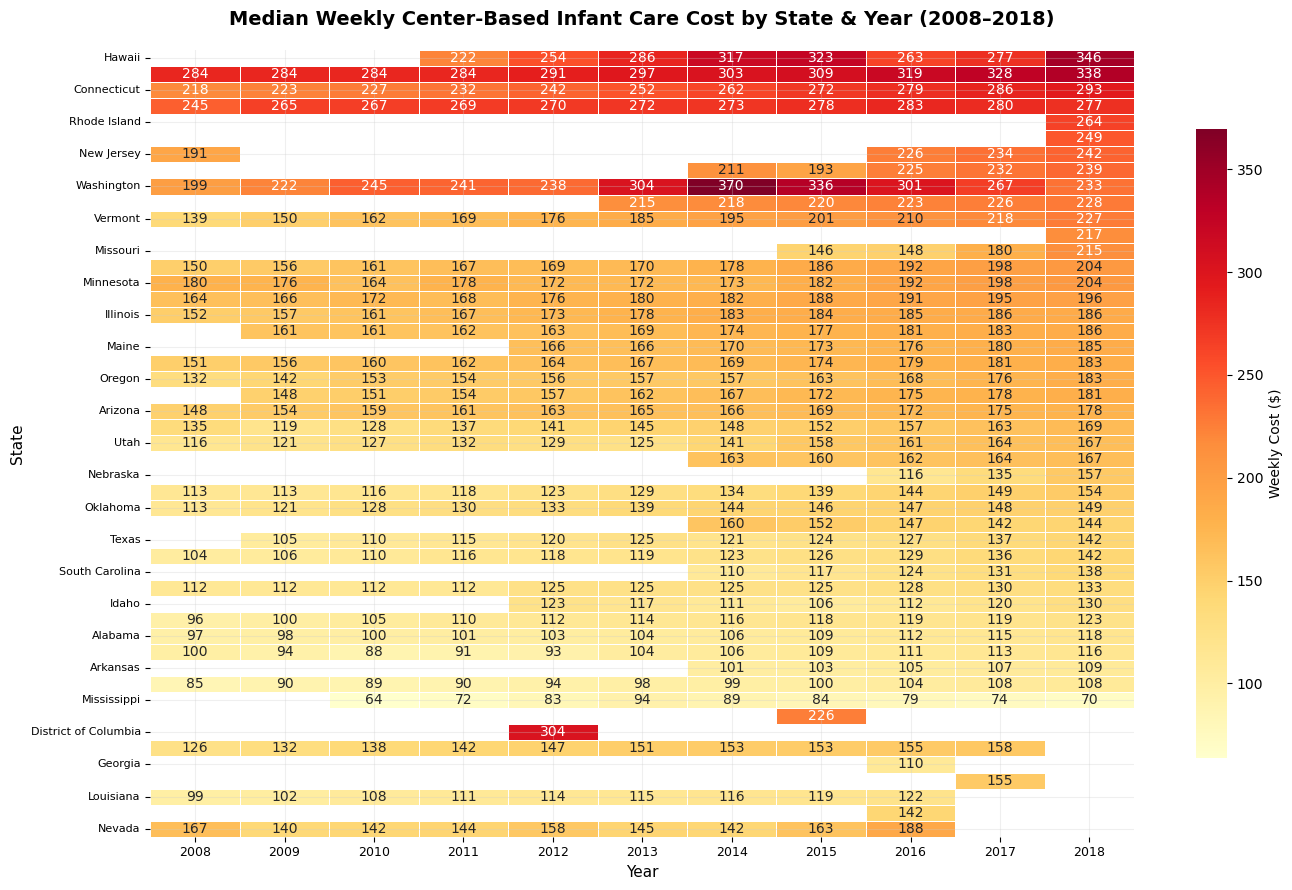

Heatmap saved.


In [23]:

# Create a pivot table: rows = states, columns = years, values = average infant care cost
pivot = df_state.pivot_table(index='State_Name', columns='Year', values='MCInfant', aggfunc='mean')

# Sort states by highest cost in 2018 (descending)
pivot = pivot.sort_values(2018, ascending=False)

# Create figure and axis with specified size
fig, ax = plt.subplots(figsize=(14, 9))

# Plot heatmap using seaborn
sns.heatmap(
    pivot,                     # Data for heatmap
    cmap='YlOrRd',             # Color scheme (yellow to red)
    annot=True,                # Show values inside cells
    fmt='.0f',                 # Format values as whole numbers
    linewidths=0.4,            # Add space between cells
    linecolor='white',         # Cell border color
    cbar_kws={'label': 'Weekly Cost ($)', 'shrink': 0.8},  # Color bar settings
    ax=ax                      # Plot on defined axis
)

# Add title to the chart
ax.set_title(
    'Median Weekly Center-Based Infant Care Cost by State & Year (2008–2018)',
    fontsize=14, fontweight='bold', pad=18
)

# Label x-axis and y-axis
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('State', fontsize=11)

# Adjust tick label sizes
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=8, rotation=0)

# Set background color
ax.set_facecolor('white')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure as an image
plt.savefig('viz1_heatmap.png', dpi=150, bbox_inches='tight')

# Display the heatmap
plt.show()

# Print confirmation message
print('Heatmap saved.')

#### Visualization 2 — Scatter Plot: Childcare Cost vs. Median Household Income

**Purpose:** Examine the income–affordability relationship. States above the regression line pay a disproportionate share of income on childcare relative to their income level.

**Audience use case:** Researchers can identify outliers where high costs *and* low incomes converge — the highest-burden counties/states requiring targeted subsidy intervention.

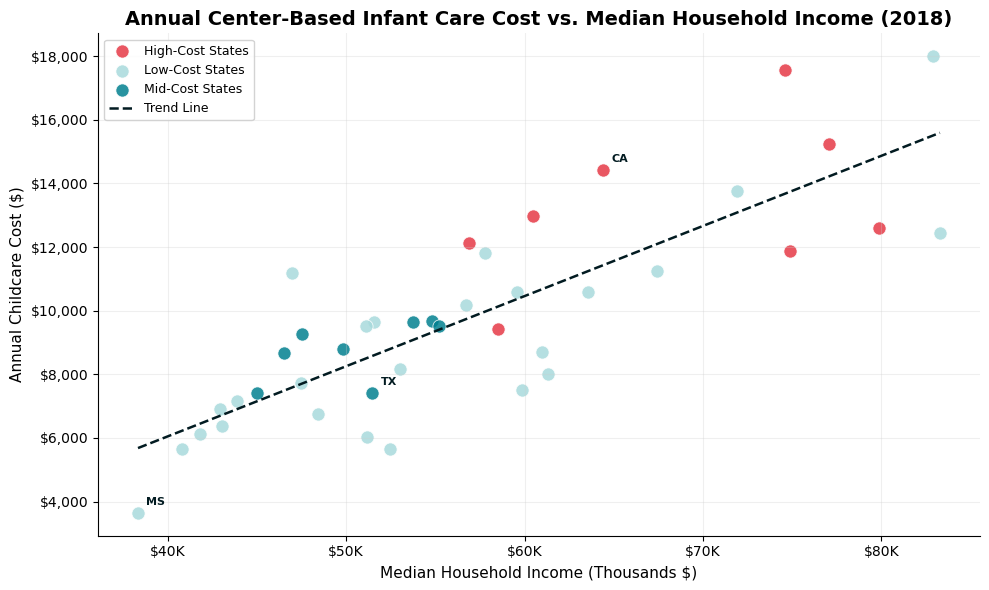

Scatter plot saved.


In [24]:

# Filter data for year 2018
df_2018 = df_state[df_state['Year'] == 2018].copy()

# Convert weekly cost to annual cost
df_2018['AnnualCost_2018'] = df_2018['MCInfant'] * 52

# Define state groups based on cost levels
high_cost   = ['CA','NY','MA','DC','WA','CT','NJ','CO','MD','VA']
mid_cost    = ['TX','FL','IL','GA','PA','OH','MI','NC','AZ','TN']

# Create a new column to categorize states into regions
df_2018['Region'] = df_2018['State'].apply(
    lambda s: 'High-Cost States' if s in high_cost
    else ('Mid-Cost States' if s in mid_cost else 'Low-Cost States')
)

# Assign colors for each region
region_colors = {
    'High-Cost States': PALETTE_ACCENT,
    'Mid-Cost States':  PALETTE_MAIN,
    'Low-Cost States':  PALETTE_LIGHT
}

# Create plot figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot scatter points for each region
for region, grp in df_2018.groupby('Region'):
    ax.scatter(
        grp['MHI'] / 1000,                 # Convert income to thousands
        grp['AnnualCost_2018'],            # Annual childcare cost
        label=region,
        color=region_colors[region],
        s=90, alpha=0.85, edgecolors='white', linewidth=0.6
    )

# Create regression (trend) line
x_vals = df_2018['MHI'] / 1000
y_vals = df_2018['AnnualCost_2018']
m, b   = np.polyfit(x_vals, y_vals, 1)   # Calculate slope and intercept
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)

# Plot trend line
ax.plot(x_line, m*x_line + b, color=PALETTE_DARK,
        linewidth=1.8, linestyle='--',
        label='Trend Line', zorder=5)

# Highlight and label selected states
for _, row in df_2018[df_2018['State'].isin(['DC','MS','CA','TX'])].iterrows():
    ax.annotate(
        row['State'],
        xy=(row['MHI']/1000, row['AnnualCost_2018']),
        xytext=(6, 6), textcoords='offset points',
        fontsize=8, color=PALETTE_DARK, fontweight='bold'
    )

# Format x-axis (income in thousands)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# Format y-axis (cost in dollars)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))

# Add title and axis labels
ax.set_title(
    'Annual Center-Based Infant Care Cost vs. Median Household Income (2018)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Median Household Income (Thousands $)', fontsize=11)
ax.set_ylabel('Annual Childcare Cost ($)', fontsize=11)

# Show legend and set background
ax.legend(fontsize=9, framealpha=0.85)
ax.set_facecolor('white')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('viz2_scatter.png', dpi=150, bbox_inches='tight')

# Display plot
plt.show()

# Confirmation message
print('Scatter plot saved.')

#### Visualization 3 — Stacked Bar Chart: Care Type Composition by Year

**Purpose:** Show how the *absolute cost stack* of different care types (Center-Based vs. Family/Home-Based) and age groups evolves from 2008 to 2018.

**Audience use case:** Analysts can see that center-based infant care consistently dominates costs and grows fastest — informing which care segments need the most policy attention.

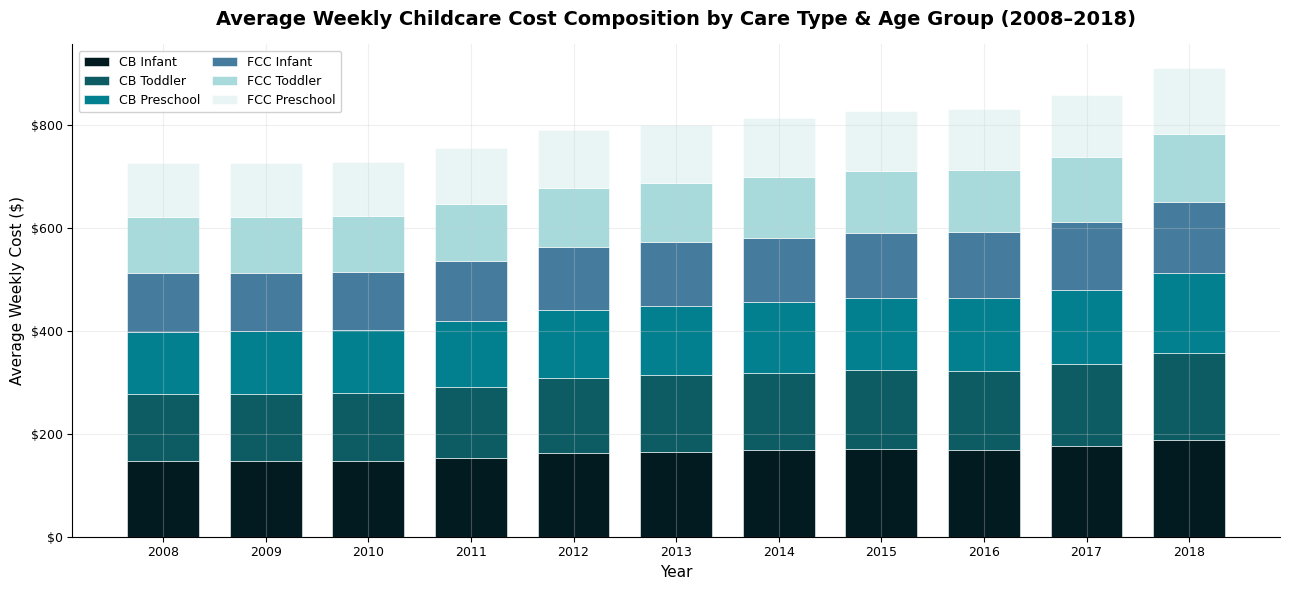

Stacked bar chart saved.


In [25]:
# Group data by Year and calculate average childcare costs
yearly = df_state.groupby('Year').agg(
    CB_Infant    = ('MCInfant',      'mean'),   # Center-based infant care
    CB_Toddler   = ('MCToddler',     'mean'),   # Center-based toddler care
    CB_Preschool = ('MCPreschool',   'mean'),   # Center-based preschool care
    FCC_Infant   = ('MFCCInfant',    'mean'),   # Family/home-based infant care
    FCC_Toddler  = ('MFCCToddler',   'mean'),   # Family/home-based toddler care
    FCC_Preschool= ('MFCCPreschool', 'mean')    # Family/home-based preschool care
).reset_index()

# Extract years for x-axis
years = yearly['Year'].tolist()

# Labels for legend
labels = ['CB Infant', 'CB Toddler', 'CB Preschool',
          'FCC Infant', 'FCC Toddler', 'FCC Preschool']

# Corresponding column names
cols_ = ['CB_Infant','CB_Toddler','CB_Preschool',
         'FCC_Infant','FCC_Toddler','FCC_Preschool']

# Define colors for each category
colors = ['#021B21','#0D5C63','#028090','#457B9D','#A8DADC','#E9F5F5']

# Create figure and axis
fig, ax = plt.subplots(figsize=(13, 6))

# Initialize bottom for stacked bars
bottom = np.zeros(len(years))

# Create stacked bar chart
for col, label, color in zip(cols_, labels, colors):
    vals = yearly[col].values  # Get values for each category
    ax.bar(years, vals, bottom=bottom, label=label,
           color=color, width=0.7, edgecolor='white', linewidth=0.4)
    bottom += vals  # Update bottom for next stack

# Add chart title and labels
ax.set_title(
    'Average Weekly Childcare Cost Composition by Care Type & Age Group (2008–2018)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Average Weekly Cost ($)', fontsize=11)

# Format x-axis and ticks
ax.set_xticks(years)
ax.tick_params(axis='both', labelsize=9)

# Format y-axis as currency
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))

# Add legend
ax.legend(
    loc='upper left', fontsize=9, framealpha=0.9,
    ncol=2, columnspacing=1.0
)

# Set background color
ax.set_facecolor('white')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('viz3_stacked_bar.png', dpi=150, bbox_inches='tight')

# Display chart
plt.show()

# Confirmation message
print('Stacked bar chart saved.')

#### Visualization 4 — Box Plot: Distribution of Childcare Costs Across States

**Purpose:** Show the spread, median, and outliers of center-based infant care costs across all states for each year. Box plots reveal whether costs are converging or diverging over time.

**Audience use case:** Researchers can evaluate whether policy changes in certain years correlate with reduced variance — a narrowing box suggests greater price convergence nationally.

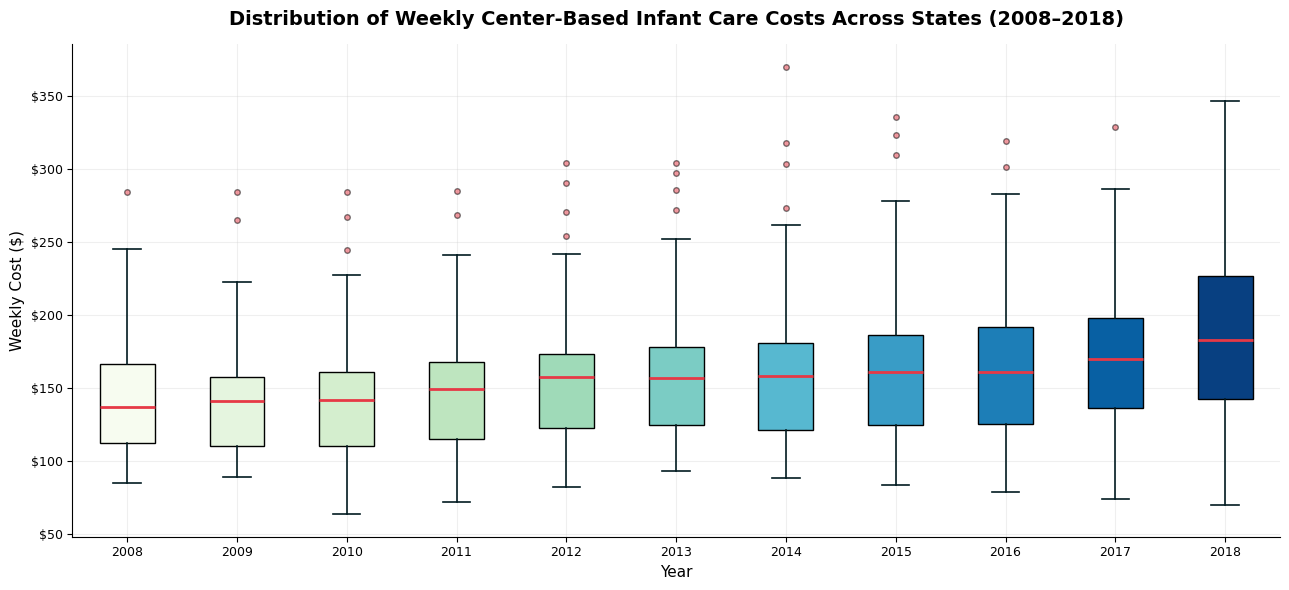

Box plot saved.


In [26]:
# Create a figure and an axis with a larger size
fig, ax = plt.subplots(figsize=(13, 6))

# Prepare data: group infant care costs by year (2008–2018)
groups = [df_state[df_state['Year'] == yr]['MCInfant'].values for yr in range(2008, 2019)]

# Create boxplot with custom styling
bp = ax.boxplot(
    groups,
    patch_artist=True,  # allows color filling
    medianprops=dict(color=PALETTE_ACCENT, linewidth=2.0),  # median line style
    whiskerprops=dict(color=PALETTE_DARK, linewidth=1.2),   # whiskers style
    capprops=dict(color=PALETTE_DARK, linewidth=1.2),       # caps style
    flierprops=dict(marker='o', markersize=4,               # outliers style
                   markerfacecolor=PALETTE_ACCENT, alpha=0.5, linestyle='none'),
    boxprops=dict(linewidth=1.0)                            # box border style
)

# Apply gradient colors to boxes (lighter to darker over years)
cmap = plt.cm.get_cmap('GnBu', 11)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(cmap(i / 10))

# Set x-axis labels (years)
ax.set_xticklabels(range(2008, 2019), fontsize=9)

# Set title and axis labels
ax.set_title(
    'Distribution of Weekly Center-Based Infant Care Costs Across States (2008–2018)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Weekly Cost ($)', fontsize=11)

# Format y-axis to display currency
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))

# Adjust tick size and background
ax.tick_params(axis='y', labelsize=9)
ax.set_facecolor('white')

# Add annotation to highlight insight about increasing variability
ax.annotate(
    'Widening spread\nindicates growing\nstate disparities',
    xy=(10, df[df['Year']==2017]['MCInfant'].max()),  # arrow point
    xytext=(7.8, df[df['Year']==2017]['MCInfant'].max() + 40),  # text position
    fontsize=8.5, color=PALETTE_DARK,
    arrowprops=dict(arrowstyle='->', color=PALETTE_DARK, lw=1.2)
)

# Adjust layout, save figure, and display plot
plt.tight_layout()
plt.savefig('viz4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Confirmation message
print('Box plot saved.')

#### Summary Statistics Table

In [40]:
# Create a national summary table grouped by year
summary = df_state.groupby('Year').agg(
    Avg_CB_Infant    = ('MCInfant', 'mean'),
    Avg_CB_Toddler   = ('MCToddler', 'mean'),
    Avg_CB_Preschool = ('MCPreschool', 'mean'),
    Avg_FCC_Infant   = ('MFCCInfant', 'mean'),
    Avg_FCC_Toddler  = ('MFCCToddler', 'mean'),
    Avg_FCC_Preschool = ('MFCCPreschool', 'mean'),
    Avg_MHI          = ('MHI', 'mean')
).round(1)

# Rename columns for better readability
summary.columns = [
    'CB Infant ($/wk)', 'CB Toddler ($/wk)', 'CB Preschool ($/wk)',
    'FCC Infant ($/wk)', 'FCC Toddler ($/wk)', 'FCC Preschool ($/wk)',
    'Median HH Income ($)'
]

# Calculate percent change from first year to last year
pct_change = ((summary.iloc[-1] / summary.iloc[0]) - 1) * 100

# Display national averages by year
print('\n=== National Average Weekly Childcare Costs ===\n')
print(summary.to_string())

# Display percent change over time
print('\n=== % Change (First Year → Last Year) ===')
print(pct_change.round(1).to_string())


=== National Average Weekly Childcare Costs ===

      CB Infant ($/wk)  CB Toddler ($/wk)  CB Preschool ($/wk)  FCC Infant ($/wk)  FCC Toddler ($/wk)  FCC Preschool ($/wk)  Median HH Income ($)
Year                                                                                                                                             
2008             146.7              131.6                120.3              114.1               108.1                 105.3               47003.1
2009             146.9              131.0                121.3              114.4               107.7                 105.2               46070.1
2010             148.0              131.5                122.2              113.6               107.9                 105.5               46338.3
2011             153.8              138.2                127.0              116.7               111.5                 108.9               48187.0
2012             162.1              146.4                133.0            

#### Key Analytical Insights

1. **Center-based infant care rose ~28% nationally** from 2008 to 2018 &#36;(146.7/week → 187.6/week),
outpacing median household income growth of ~21% over the same period — meaning families
lost ground on childcare affordability every year.

2. **All care types rose faster than income after 2011.** Costs were relatively flat from
2008–2010 (under &#36;150/week for CB infant care), then accelerated sharply from 2011 onward —
suggesting post-recession economic pressures drove a structural increase in provider costs.

3. **Center-based care is consistently more expensive than family/home-based care**, with
CB infant care averaged &#36;48 per week, more than FCC infant care in 2018 (187.6 vs. 139.7).
However, both track the same upward trajectory — indicating systemic cost drivers rather
than provider-type-specific pressures.

4. **Toddler care saw the steepest increase** among all age groups at +29.4% (2008–2018),
slightly outpacing infant (+27.9%) and preschool (+28.0%) center-based care — signaling
that the 24–35 month age group is becoming a growing pressure point for families.

5. **The widening box-plot spread post-2013** reflects growing state-level divergence.
The jump from &#36;(165/week (2013) to 187.6/week (2018)) for CB infant care, combined with
increasing variance, suggesting that national policy pressures have had heterogeneous effects
across states — warranting state-specific rather than blanket federal policy responses.